In [1]:
import matplotlib.pyplot as plt
import numpy as np
from p3.aoSystem.fourierModel import fourierModel
from p3.aoSystem.frequencyDomain import frequencyDomain

Cupy import failed. P3 will fall back to CPU use.
103
Cupy import failed. MASTSEL will fall back to CPU use.


In [2]:
fao = fourierModel(path_ini='/raid1/mmenessini/git/P3/p3/aoSystem/parFiles/SOUL.ini',display=False, verbose=True,getErrorBreakDown=True)

108
extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2

_____ ERROR BREAKDOWN  ON-AXIS_____
------------------------------------------
.Image Strehl at 2.15micron:	94.55%
.Maréchal Strehl at 2.15micron:	94.47%
.Residual wavefront error:	81.59nm
.NCPA residual:			0.00nm
.Fitting error:			71.61nm
.Differential refraction:	0.00nm
.Chromatic error:		12.76nm
.Aliasing error:		21.31nm
.Noise error:			20.75nm
.Spatio-temporal error:		21.93nm
.Wind-shake error:		0.00nm
.Additionnal jitter:		0.00mas / 0.00nm
.Extra error:			0.00nm
-------------------------------------------
.Sole servoLag error:		21.93nm
.Sole reconstruction error:	0.00nm
-------------------------------------------
.Sole anisoplanatism error:	0.00nm
-------------------------------------------

EXECUTION TIME BREAKDOWN

Total calculation time:                          237.3 ms
AO system model initialization:                    3.7 

Text(0.5, 1.0, 'Aliasing')

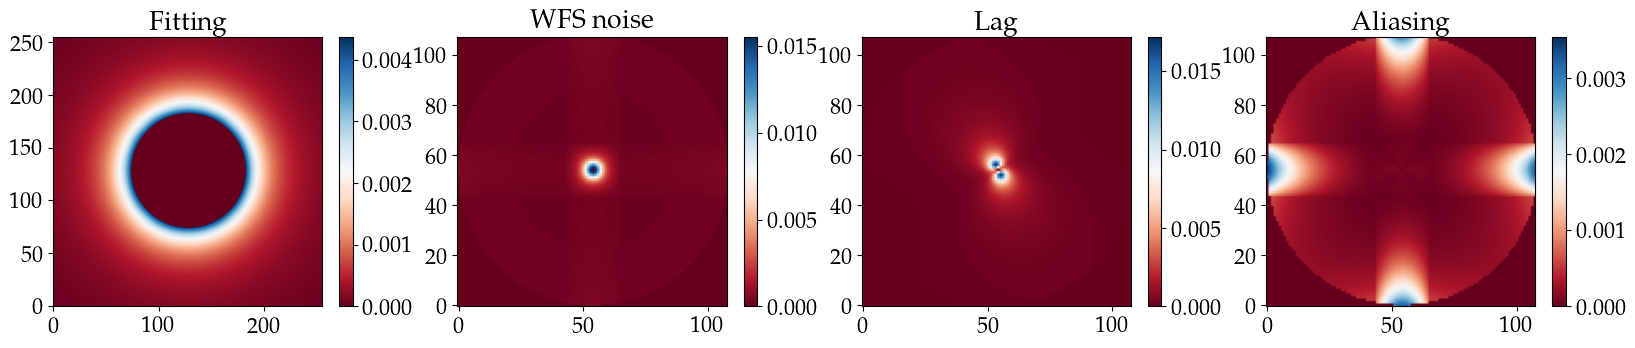

In [3]:
aliasPSD = fao.aliasingPSD()
servoLagPSD = fao.servoLagPSD()
fittingPSD = fao.fittingPSD()
noisePSD = fao.noisePSD()

plt.figure(figsize=(20,3.5))
plt.subplot(1,4,1)
plt.imshow(fittingPSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Fitting')
plt.subplot(1,4,2)
plt.imshow(noisePSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('WFS noise')
plt.subplot(1,4,3)
plt.imshow(servoLagPSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Lag')
plt.subplot(1,4,4)
plt.imshow(aliasPSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Aliasing')

In [4]:
def get_flux(fao, mag:float, B0=10**10):
    thrp = fao.ao.wfs.detector[0].transmittance[0]
    area = np.pi/4*fao.ao.tel.D**2*(1-fao.ao.tel.obsRatio**2)
    thrp *= 1.0-np.exp(-(0.35+0.72*fao.ao.wfs.optics[0].modulation))
    return area * thrp * B0 * 10**(-mag/2.5)

def update_ao_pars(fao, delay=None, gain=None, mag=None, fs=None, Nsubap=None, nModes=None, rMod=None, binning=None):
    
    if gain is not None:
        fao.ao.rtc.holoop['gain'] = gain
    if delay is not None:
        fao.ao.rtc.holoop['delay'] = delay
    if fs is not None:
        fao.ao.rtc.holoop['rate'] = fs
    if rMod is not None:
        fao.ao.wfs.optics[0].modulation = rMod
    if Nsubap is not None:
        fao.ao.wfs.optics[0].nL = Nsubap
        fao.ao.wfs.optics[0].dsub = fao.ao.tel.D/Nsubap

    if binning is not None:
        fao.ao.wfs.detector[0].binning = binning
                
    if mag is not None:
        total_flux = get_flux(fao, mag)
    else:
        total_flux = fao.ao.wfs.detector[0].nph * fao.ao.rtc.holoop['rate'] * fao.ao.wfs.optics[0].nL**2 * np.pi/4
    fs = fao.ao.rtc.holoop['rate']
    nSubap = fao.ao.wfs.optics[0].nL**2 * np.pi/4
    flux_per_sub = total_flux / fs / nSubap
    fao.ao.wfs.detector[0].nph = flux_per_sub

    if nModes is not None:
        nActs = np.sqrt(nModes*4/np.pi)
        fao.ao.dms.nActu1D = nActs
        fao.ao.dms.pitch = fao.ao.tel.D/nActs
        fao.freq = frequencyDomain(
                    fao.ao,
                    nyquistSampling=fao.nyquistSampling,
                    computeFocalAnisoCov=fao.computeFocalAnisoCov,
                    dtype=fao.dtype
                )
    
    fao.ao.wfs.processing.noiseVar = [None]
    

def get_error_breakdown(fao):
    fao.ao.error = False
    fao.getErrorBreakdown = True
    fao.initComputations()

    # try:
    idCenter = fao.ao.src.zenith.argmin()
    error = {'fitting': fao.wfeFit, 'lag': fao.wfeS, 'noise': fao.wfeN[idCenter], 'aliasing': fao.wfeAl, 'total': fao.wfeTot[idCenter]}
    # except IndexError:
    #     error = {'fitting': fao.wfeFit, 'noise': fao.wfeN, 'aliasing': fao.wfeAl, 'lag': fao.wfeS, 'total': fao.wfeTot}

    return error

fao.verbose = False

In [5]:
eb0 = get_error_breakdown(fao)
# print(fao.ao.wfs.detector[0].nph)
update_ao_pars(fao, mag = 7.5, fs = 1500, delay = 3.5, gain = 0.5)
eb1 = get_error_breakdown(fao)
print(fao.ao.wfs.detector[0].nph)

108
108
255.46825620818066


In [6]:
print(eb0,'\n',eb1)

{'fitting': 71.61429477285542, 'lag': 21.931072673094867, 'noise': 20.75469005739251, 'aliasing': 21.314597498136923, 'total': 81.59300657896001} 
 {'fitting': 71.61429477285542, 'lag': 22.10468227229554, 'noise': 30.88867478921366, 'aliasing': 20.709805958191517, 'total': 84.63451317006862}
